In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Set professional plot style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
plt.rcParams['legend.fontsize'] = 11

# Read data
df = pd.read_csv('../results/omp_results.csv')
print("OpenMP Scaling Data:")
print(df)

OpenMP Scaling Data:
   Threads  TotalTime  CommTime  CompTime  Speedup  Efficiency
0        1   8.930621  0.029637  8.880738   1.0000      1.0000
1        2   4.633545  0.017844  4.602882   1.9273      0.9636
2        4   3.051744  0.013862  3.026812   2.9263      0.7315
3        8   2.894185  0.011790  2.865516   3.0857      0.3857
4       16   0.642884  0.005594  0.617383  13.8914      0.8682
5       32   0.321523  0.008217  0.274333  27.7759      0.8679
6       64   0.266515  0.015925  0.170230  33.5088      0.5235
7      128   0.366368  0.037434  0.138648  24.3760      0.1904


✅ Saved: omp_speedup.png


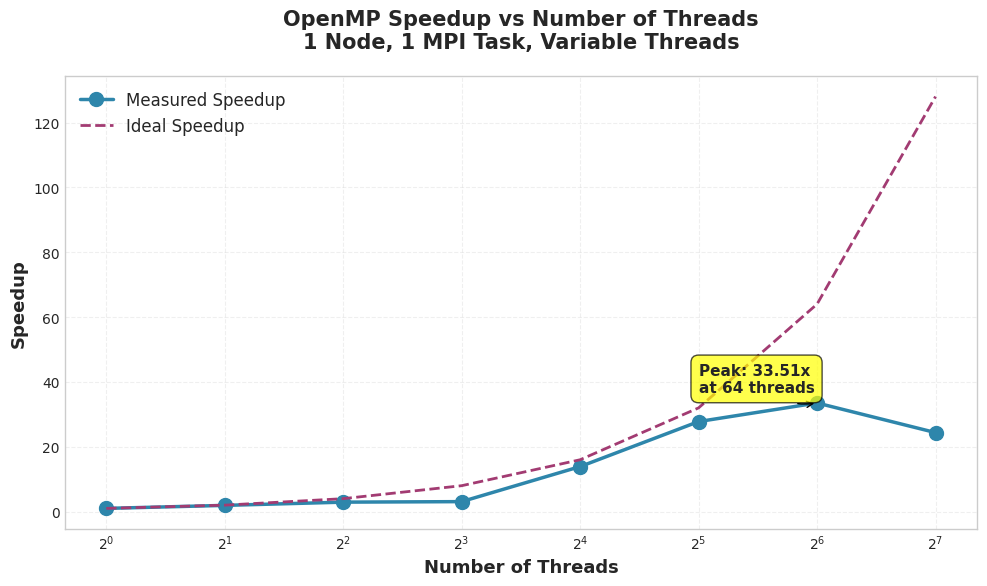

In [2]:
# ============================================================================
# PLOT 1: Speedup vs Number of Threads
# ============================================================================
fig, ax = plt.subplots(figsize=(10, 6))

# Plot measured speedup
ax.plot(df['Threads'], df['Speedup'], 
        'o-', linewidth=2.5, markersize=10, 
        color='#2E86AB', label='Measured Speedup')

# Plot ideal speedup (linear)
ax.plot(df['Threads'], df['Threads'], 
        '--', linewidth=2, 
        color='#A23B72', label='Ideal Speedup')

ax.set_xlabel('Number of Threads', fontsize=13, fontweight='bold')
ax.set_ylabel('Speedup', fontsize=13, fontweight='bold')
ax.set_title('OpenMP Speedup vs Number of Threads\n1 Node, 1 MPI Task, Variable Threads', 
             fontsize=15, fontweight='bold', pad=20)
ax.legend(fontsize=12, loc='upper left')
ax.grid(True, alpha=0.3, linestyle='--')
ax.set_xscale('log', base=2)  # Log scale for better visualization

# Add annotations for peak speedup
max_speedup_idx = df['Speedup'].idxmax()
max_speedup = df.loc[max_speedup_idx, 'Speedup']
max_threads = df.loc[max_speedup_idx, 'Threads']
ax.annotate(f'Peak: {max_speedup:.2f}x\nat {max_threads} threads',
            xy=(max_threads, max_speedup),
            xytext=(max_threads*0.5, max_speedup*1.1),
            fontsize=11, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.7),
            arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0.3'))

plt.tight_layout()
plt.savefig('omp_speedup.png', dpi=300, bbox_inches='tight')
print("✅ Saved: omp_speedup.png")
plt.show()

✅ Saved: omp_efficiency.png


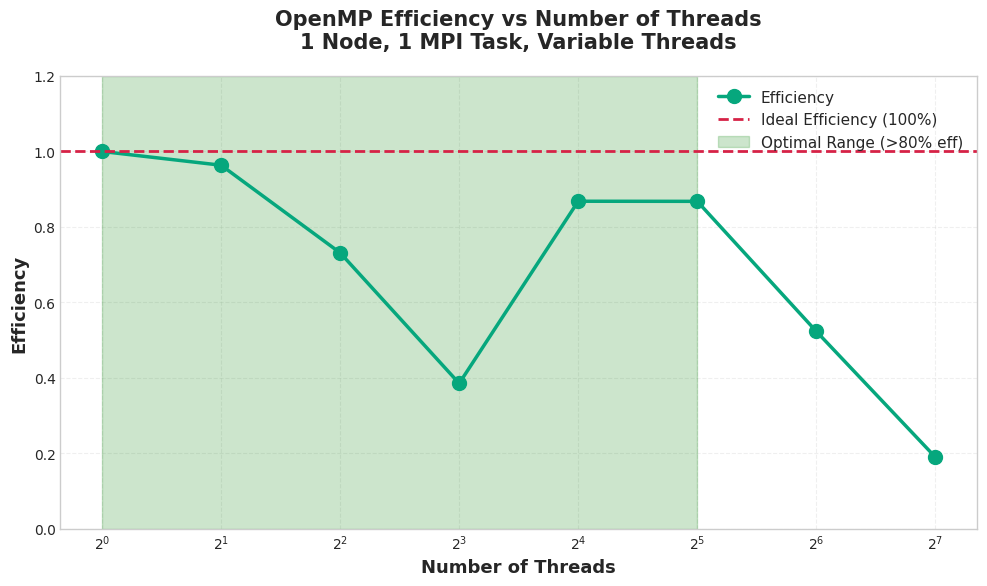

In [3]:
# ============================================================================
# PLOT 2: Efficiency vs Number of Threads
# ============================================================================
fig, ax = plt.subplots(figsize=(10, 6))

# Plot efficiency
ax.plot(df['Threads'], df['Efficiency'], 
        'o-', linewidth=2.5, markersize=10, 
        color='#06A77D', label='Efficiency')

# Ideal efficiency line
ax.axhline(y=1.0, color='#D62246', linestyle='--', linewidth=2, label='Ideal Efficiency (100%)')

ax.set_xlabel('Number of Threads', fontsize=13, fontweight='bold')
ax.set_ylabel('Efficiency', fontsize=13, fontweight='bold')
ax.set_title('OpenMP Efficiency vs Number of Threads\n1 Node, 1 MPI Task, Variable Threads', 
             fontsize=15, fontweight='bold', pad=20)
ax.legend(fontsize=12, loc='best')
ax.grid(True, alpha=0.3, linestyle='--')
ax.set_xscale('log', base=2)
ax.set_ylim([0, 1.2])

# Highlight optimal range (efficiency > 80%)
optimal_df = df[df['Efficiency'] > 0.8]
if len(optimal_df) > 0:
    ax.axvspan(optimal_df['Threads'].min(), optimal_df['Threads'].max(), 
               alpha=0.2, color='green', label=f'Optimal Range (>80% eff)')
    ax.legend(fontsize=11, loc='best')

plt.tight_layout()
plt.savefig('omp_efficiency.png', dpi=300, bbox_inches='tight')
print("✅ Saved: omp_efficiency.png")
plt.show()

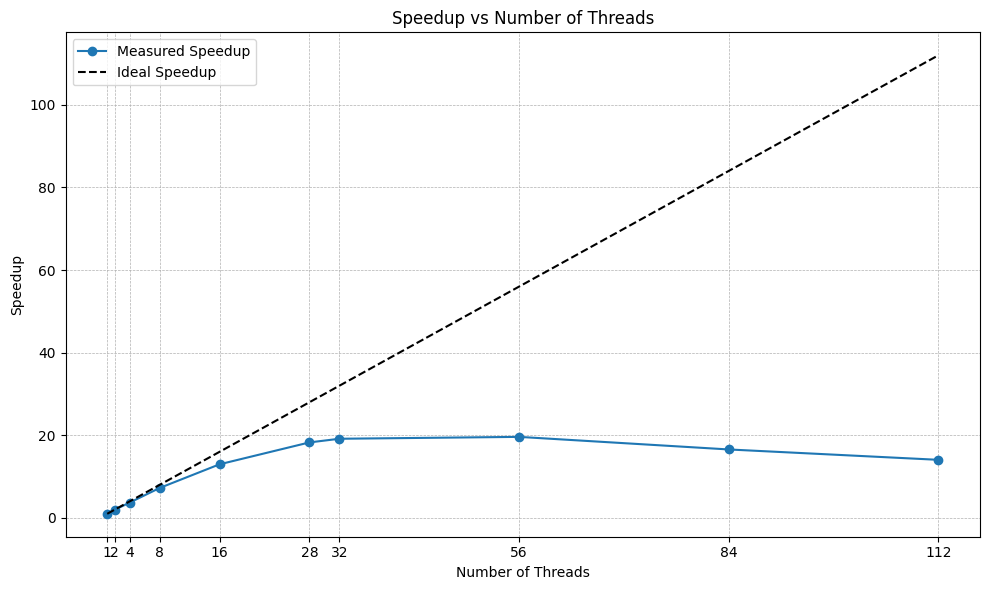

In [14]:
plt.figure(figsize=(10, 6))
plt.plot(df['Thread'], df['Speedup'], marker='o', label='Measured Speedup')
plt.plot(df['Thread'], df['Thread'], 'k--', label='Ideal Speedup')  # Ideal: speedup = threads
plt.xlabel('Number of Threads')
plt.ylabel('Speedup')
plt.title('Speedup vs Number of Threads')
plt.xscale('linear')
plt.xticks(df['Thread'])
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.legend()
plt.tight_layout()
plt.show()

✅ Saved: omp_computation_time.png


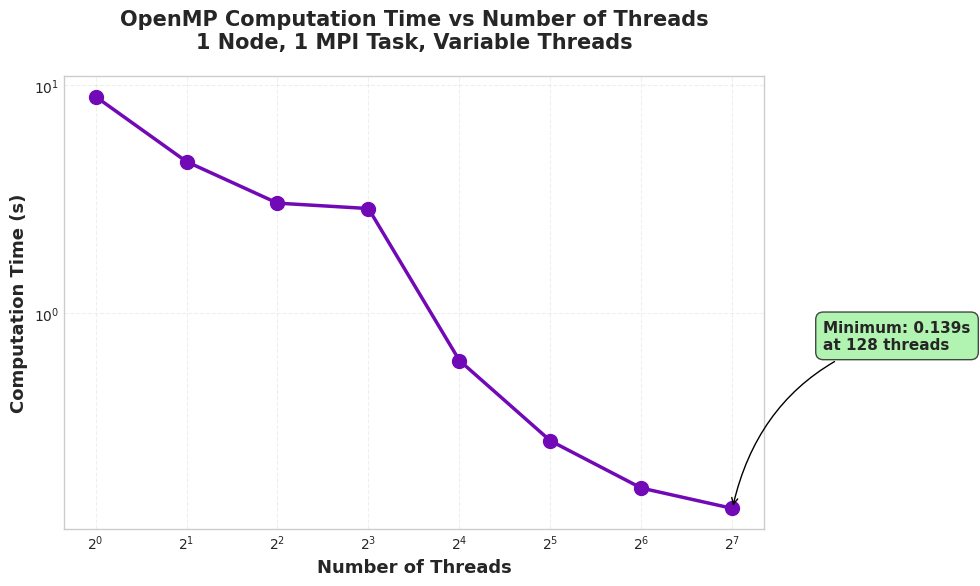

In [4]:
# ============================================================================
# PLOT 3: Computation Time vs Number of Threads
# ============================================================================
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(df['Threads'], df['CompTime'], 
        'o-', linewidth=2.5, markersize=10, 
        color='#7209B7', label='Computation Time')

ax.set_xlabel('Number of Threads', fontsize=13, fontweight='bold')
ax.set_ylabel('Computation Time (s)', fontsize=13, fontweight='bold')
ax.set_title('OpenMP Computation Time vs Number of Threads\n1 Node, 1 MPI Task, Variable Threads', 
             fontsize=15, fontweight='bold', pad=20)
ax.grid(True, alpha=0.3, linestyle='--')
ax.set_xscale('log', base=2)
ax.set_yscale('log')

# Add annotation for minimum time
min_time_idx = df['CompTime'].idxmin()
min_time = df.loc[min_time_idx, 'CompTime']
min_threads = df.loc[min_time_idx, 'Threads']
ax.annotate(f'Minimum: {min_time:.3f}s\nat {min_threads} threads',
            xy=(min_threads, min_time),
            xytext=(min_threads*2, min_time*5),
            fontsize=11, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='lightgreen', alpha=0.7),
            arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0.3'))

plt.tight_layout()
plt.savefig('omp_computation_time.png', dpi=300, bbox_inches='tight')
print("✅ Saved: omp_computation_time.png")
plt.show()

In [5]:
print("\n" + "="*60)
print("OPENMP SCALING ANALYSIS SUMMARY")
print("="*60)
print(f"Peak Speedup: {df['Speedup'].max():.2f}x at {df.loc[df['Speedup'].idxmax(), 'Threads']} threads")
print(f"Best Efficiency: {df['Efficiency'].max():.2%} at {df.loc[df['Efficiency'].idxmax(), 'Threads']} threads")
print(f"Optimal Thread Count (>80% eff): {optimal_df['Threads'].min()}-{optimal_df['Threads'].max()}")
print(f"Minimum Computation Time: {df['CompTime'].min():.3f}s at {df.loc[df['CompTime'].idxmin(), 'Threads']} threads")
print("="*60)


OPENMP SCALING ANALYSIS SUMMARY
Peak Speedup: 33.51x at 64 threads
Best Efficiency: 100.00% at 1 threads
Optimal Thread Count (>80% eff): 1-32
Minimum Computation Time: 0.139s at 128 threads
